In [1]:
import xgi
import numpy as np
from tqdm import tqdm
from had_model import HAD_model
from hypergraph_null_models import edge_shuffled_hypergraph
import matplotlib.pyplot as plt

# Generate or upload a hypergraph

#### Generate a random hypergraph

In [3]:
N = 300

#ps = [1e-3, 1e-4, 1e-6]
#H = xgi.fast_random_hypergraph(N, ps, seed=0)
#tag = f'Random_N_{N}_M_{len(ps)+1}'  # to fix for saving plots!

M = 3
k_avg = 10
H = xgi.uniform_erdos_renyi_hypergraph(N, M, k_avg, p_type="degree")
tag = f'ER{M}_{N}_{k_avg}'   # to fix for saving plots!

H.cleanup()

print(H, '\nHyperedge sizes:', xgi.unique_edge_sizes(H), '\nConnected:',  xgi.is_connected(H))

Unnamed Hypergraph with 300 nodes and 791 hyperedges 
Hyperedge sizes: [2, 3, 4] 
Connected: True


#### Or upload a real-world structure

In [19]:
tag = 'Thiers13'
with open(f'../data/SocioPatterns/aggr_15min_cliques_thr1_{tag}.json') as file: 
            data = json.load(file)
H = xgi.from_hyperedge_list(data)
# relabel and remove eventual multiple edges
H.cleanup(isolates=True, singletons=True, connected=False)

# Pairwise projections
#G = xgi.to_graph(H)
#H = xgi.Hypergraph(list(G.edges))
#tag = f'Proj_{tag}'

# ER reshuffled hypergraph
H = edge_shuffled_hypergraph(H, seed=0)
tag = f'Shuf_{tag}'

N = len(H.nodes)
print(H, '\nHyperedge sizes:', xgi.unique_edge_sizes(H), '\nConnected:',  xgi.is_connected(H))

Unnamed Hypergraph with 327 nodes and 4795 hyperedges 
Hyperedge sizes: [2, 3, 4, 5, 6, 7] 
Connected: True


# Measure some observables as a function of $\epsilon$

100%|███████████████████████████████████████████| 40/40 [15:05<00:00, 22.64s/it]


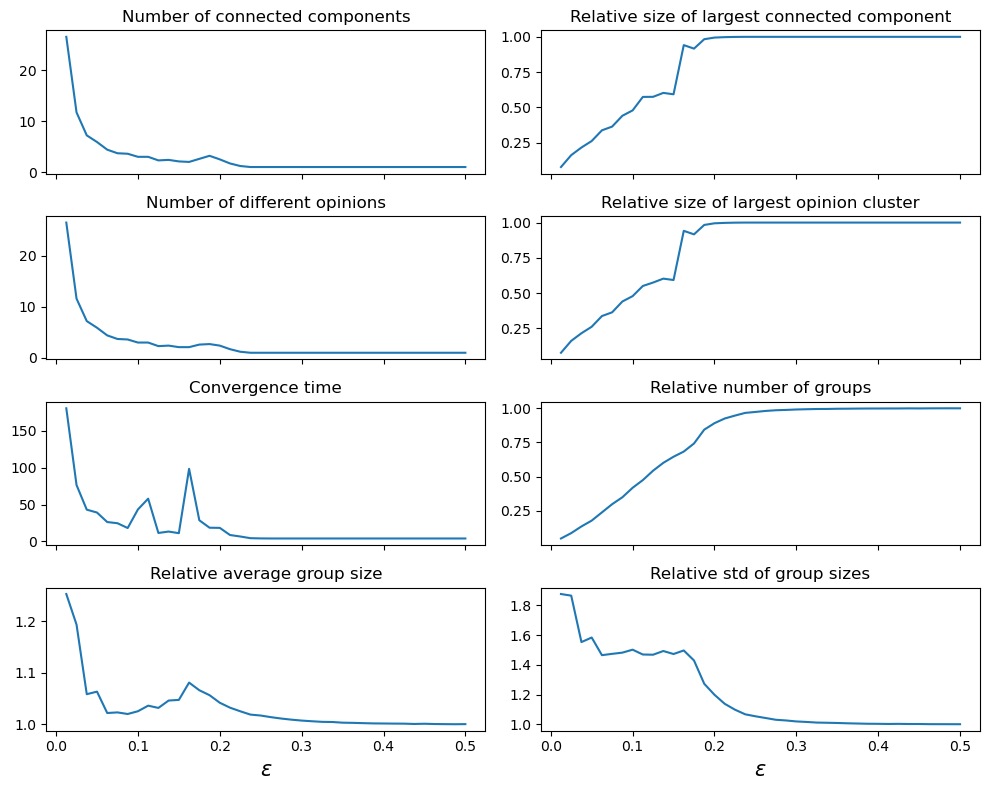

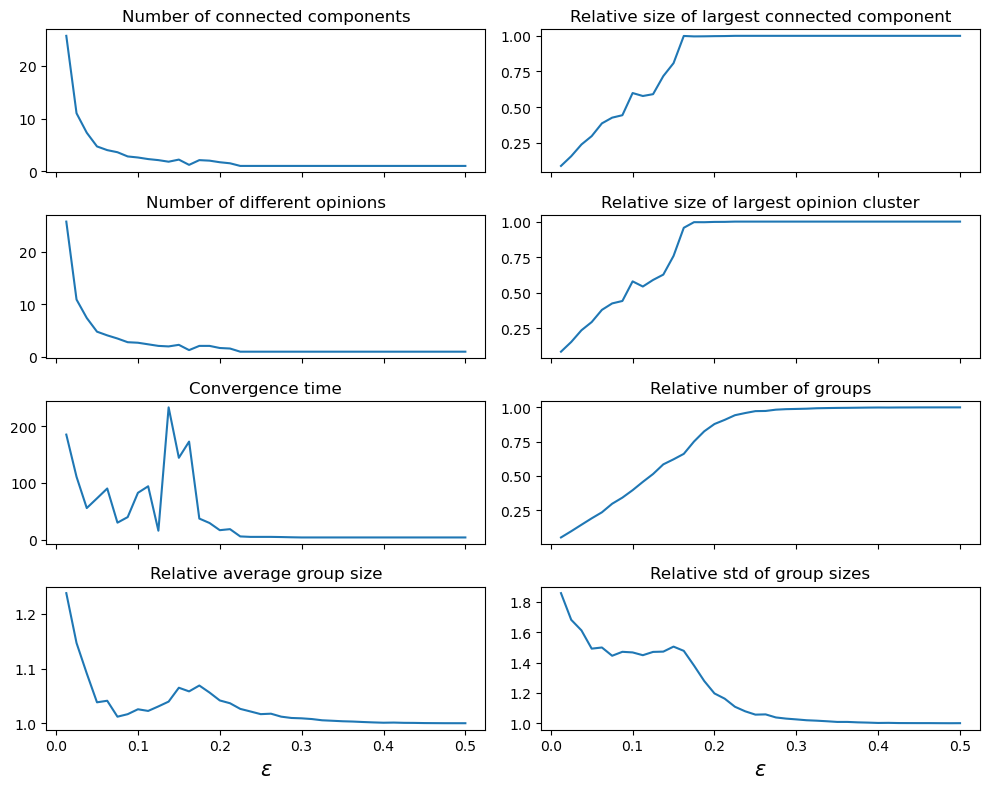

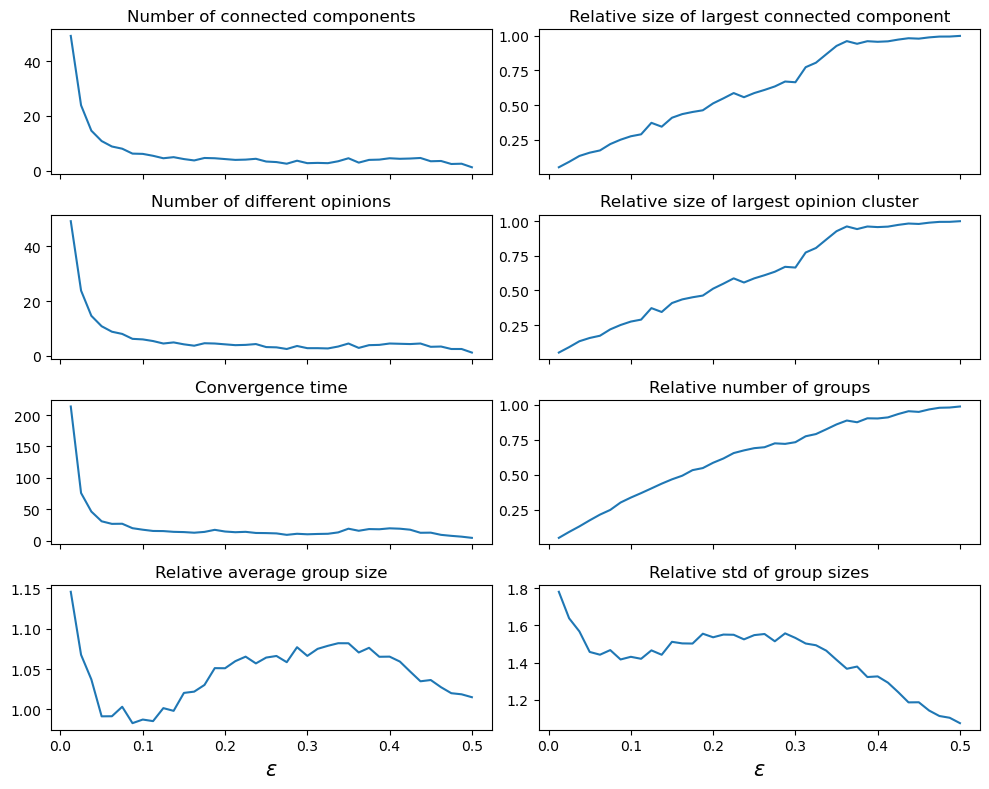

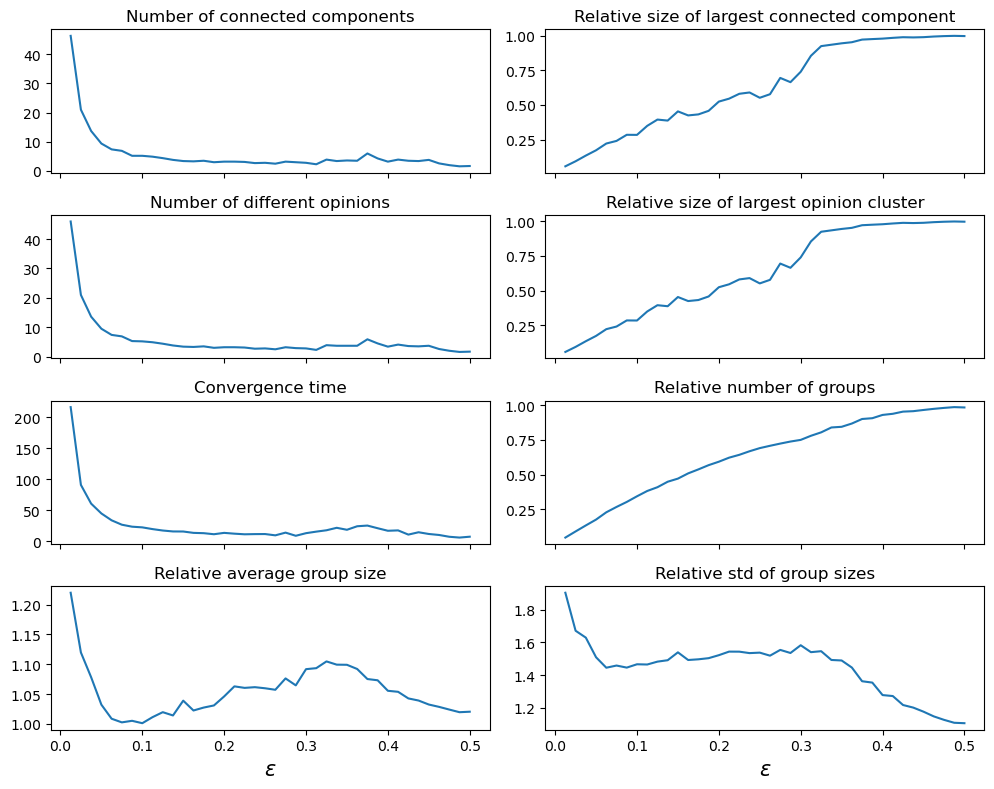

In [25]:
groups_0 = H.edges.members()
sizes_0 = [len(e) for e in groups_0]
s_avg_0 = np.mean(sizes_0)        # average group size in the initial hypergraph
s_std_0 = np.std(sizes_0, ddof=1) # std of group sizes in the initial hypergraph

epsilons = np.linspace(0., 0.5, num=41)[1:]
iterations = 10 # numbers of iteration for each epsilon

# set model parameters 
#params = ['std', 1.0, True, 'random']

# cycle over different parameters of the model
for pr0 in ['std', 'max_min']:
    for pr1 in [1.0, 0.5]:
        for pr2 in [True]:#, False]:
            for pr3 in ['random']:#, 'degree', 'extreme']:
                
                # All below quantities are computed at the steady state, as a function of epsilon
                ncc, scc = [], []      # number of connected components and size of the largest one
                nop, sop = [], []      # number of opinions clusters and size of the largest one
                t_conv, ngr = [], []   # convergence time and number of groups
                s_avg, s_std = [], []  # relative average and std of group sizes (w.r.t. the initial hypergraph)
                              
                for eps in tqdm(epsilons):
                
                    ncc_it, scc_it = [], []
                    nop_it, sop_it = [], []
                    t_conv_it, ngr_it = [], []
                    s_avg_it, s_std_it = [], []
                    
                    for it in range(iterations):
                        
                        Model = HAD_model(eps, groups_0)
                        results = Model.simulate(condition=pr0, mu=pr1, split_overlap=pr2, split_seed=pr3)
                        opinions = results['opinions']
                        groups = results['groups']
                        
                        # number of connected components and size of the largest one
                        hedges = groups[-1]
                        h = xgi.Hypergraph(hedges)
                        # list of connected components
                        cc = [j for j in xgi.connected_components(h)]
                        ncc_it.append( len(cc) )
                        scc_it.append( max([len(i) for i in cc]) / N )
                
                        # number of opinion clusters and relative size of largest one
                        ops_end = [opinions[n][-1] for n in H.nodes]
                        ops_end = np.round(ops_end, 3) 
                        ops_unique = set(ops_end)
                        x = 0
                        # count max number of equal opinions (x)
                        for v in ops_unique:
                            y = sum(np.where(ops_end==v, 1, 0))
                            x = max(x,y)
                        sop_it.append(x/N)
                        nop_it.append( len(ops_unique) )
                
                        # convergence time and relative number of groups
                        t_conv_it.append( len(groups) )
                        ngr_it.append( len(groups[-1]) / len(groups_0) )
                        
                        # relative avg and std of group sizes
                        sizes_end_it = [len(e) for e in groups[-1]]
                        s_avg_it.append( np.mean(sizes_end_it) / s_avg_0 )
                        s_std_it.append( np.std(sizes_end_it, ddof=1) / s_std_0 )
                        
                    ncc.append(np.mean(ncc_it))
                    scc.append(np.mean(scc_it))
                    nop.append(np.mean(nop_it))
                    sop.append(np.mean(sop_it))
                    t_conv.append(np.mean(t_conv_it))
                    ngr.append(np.mean(ngr_it))
                    s_avg.append(np.mean(s_avg_it))
                    s_std.append(np.mean(s_std_it))
                
                             
                # plot results and save figure
                fig, axs = plt.subplots(4,2, sharex=True, figsize=(10,8))
                
                axs[0,0].plot(epsilons, ncc)
                axs[0,0].set_title('Number of connected components')
                
                axs[0,1].plot(epsilons, scc)
                axs[0,1].set_title('Relative size of largest connected component')
                
                axs[1,0].plot(epsilons, nop)
                axs[1,0].set_title('Number of different opinions')
                
                axs[1,1].plot(epsilons, sop)
                axs[1,1].set_title('Relative size of largest opinion cluster')
                
                axs[2,0].plot(epsilons, t_conv)
                axs[2,0].set_title('Convergence time')
                
                axs[2,1].plot(epsilons, ngr)
                axs[2,1].set_title('Relative number of groups')
                
                axs[3,0].plot(epsilons, s_avg)
                axs[3,0].set_title('Relative average group size')
                
                axs[3,1].plot(epsilons, s_std)
                axs[3,1].set_title('Relative std of group sizes')
                
                axs[3,0].set_xlabel(r'$\epsilon$', fontsize=15)
                axs[3,1].set_xlabel(r'$\epsilon$', fontsize=15)
                
                plt.tight_layout()
                plt.savefig(f'../figures/{tag}/{tag}_{pr0}_{pr1}_{pr2}_{pr3}.jpg')

In [27]:
s_avg_0

3.092387904066736